# **Abalone Age Prediction Using Machine Learning**

---

### Course:
Machine Learning

### Assignment:
ML Project

### Dataset:
Abalone Dataset (UCI Machine Learning Repository)

### Students:
Katsiaryna Schastnaya  
Evgeniya Yankovich

---




## **Dataset Description**
The dataset contains measurements of abalone specimens, such as length, diameter, weight, and sex.
The target variable is the number of rings, which is directly related to the age of abalone.

## **Part 1: Exploratory Data Analysis & Preprocessing**

0.1. Introduction  
0.2. Data Loading  
1.1. Target Analysis & Problem Definition  
1.2. Feature Analysis   
1.3. Correlation Analysis  
1.4. Data Preprocessing  
1.5. Dimensionality Reduction  
1.6. Feature Generation  
1.7. Summary & Next Steps  


## **0.1 Introduction**

The goal of this part is to perform EDA and data preprocessing
for the Abalone dataset. The final objective is to prepare the dataset for building a machine
learning model to predict the age of abalone based on its physical characteristics.


## **0.2. Data Loading**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [26]:
# Visualisation settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [27]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"

columns = [
    "Sex", "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight",
    "Viscera_weight", "Shell_weight", "Rings"
]

df = pd.read_csv(url, header=None, names=columns)
df.head()



,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## **1.1 Target Analysis & Problem Definition**



### **Target Variable Description**

The target variable in the Abalone dataset is `Rings`, which represents the number of growth rings observed on the shell of an abalone. These rings are formed approximately on an annual basis and are commonly used in marine biology as a proxy for estimating the age of the organism.

The actual age of an abalone can be approximated using the following relationship:

`Age = Rings + 1.5`,

where the constant accounts for the initial growth period before the first ring is formed.

From a data perspective, the Rings variable:
* is **quantitative and numeric**,
* takes **discrete integer values**,
* is **ordered**, with meaningful differences between values,
* typically ranges from low single digits to around 30.

In [28]:
df["Rings"].describe()


count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: Rings, dtype: float64

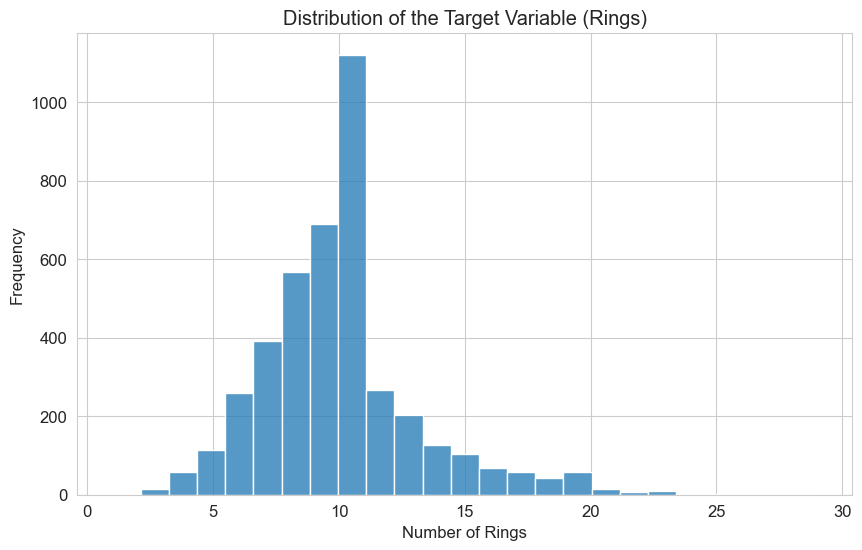

In [29]:
plt.figure()
sns.histplot(df["Rings"], bins=25)
plt.title("Distribution of the Target Variable (Rings)")
plt.xlabel("Number of Rings")
plt.ylabel("Frequency")
plt.show()


The distribution of the target variable is slightly right-skewed, with most abalone specimens having
a moderate number of rings. This suggests that extreme ages are relatively rare.


### **ML Task Definition**

The problem is formulated as a supervised learning regression task.

Given a set of physical and biological attributes of an abalone (such as length, diameter, height, and various weight measurements), the objective is to predict the numerical value of `Rings`, and consequently estimate the age of the abalone.

Formally, the task is to learn a function:

`𝑓(𝑋) → 𝑦`

where:
𝑋 is a vector of observed features describing the abalone,
𝑦 is the target variable Rings.

### **Justification for Regression**

The target variable `Rings` is a **numeric, ordered variable** with a meaningful scale, where differences between values correspond to differences in age.

Preserving this numerical information is important, as converting the target into categories would lead to information loss and reduced prediction accuracy.

A **regression** approach is therefore appropriate, as it is designed to predict continuous or quasi-continuous values and to penalize errors proportionally to their magnitude.

From a domain perspective, determining the age of an abalone using traditional methods is **destructive and time-consuming**, while prediction based on physical measurements offers a **non-destructive and cost-effective alternative**. In practical applications such as aquaculture and ecological monitoring, **precise numerical age estimates** are more valuable than coarse categorical labels. For these reasons, the problem is formulated as a **supervised regression task**.

## **1.2 Feature Analysis**

The Abalone dataset contains eight input features describing physical and biological characteristics of each abalone. These features include one categorical variable and seven numerical variables.

### **Feature Overview**

| Feature          | Type                   | Description                                             |
| ---------------- | ---------------------- | ------------------------------------------------------- |
| `Sex`            | Categorical            | Sex of the abalone: Male (M), Female (F), or Infant (I) |
| `Length`         | Numerical (continuous) | Longest shell measurement (mm)                          |
| `Diameter`       | Numerical (continuous) | Diameter perpendicular to length (mm)                   |
| `Height`         | Numerical (continuous) | Height of the abalone with meat inside (mm)             |
| `Whole weight`   | Numerical (continuous) | Total weight of the abalone (grams)                     |
| `Shucked weight` | Numerical (continuous) | Weight of the meat after shell removal (grams)          |
| `Viscera weight` | Numerical (continuous) | Weight of internal organs (grams)                       |
| `Shell weight`   | Numerical (continuous) | Weight of the shell after drying (grams)                |


In [30]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


The dataset contains no missing values. All numerical features are stored using floating-point format,
while the `Sex` feature is categorical.


In [31]:
df.describe()


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


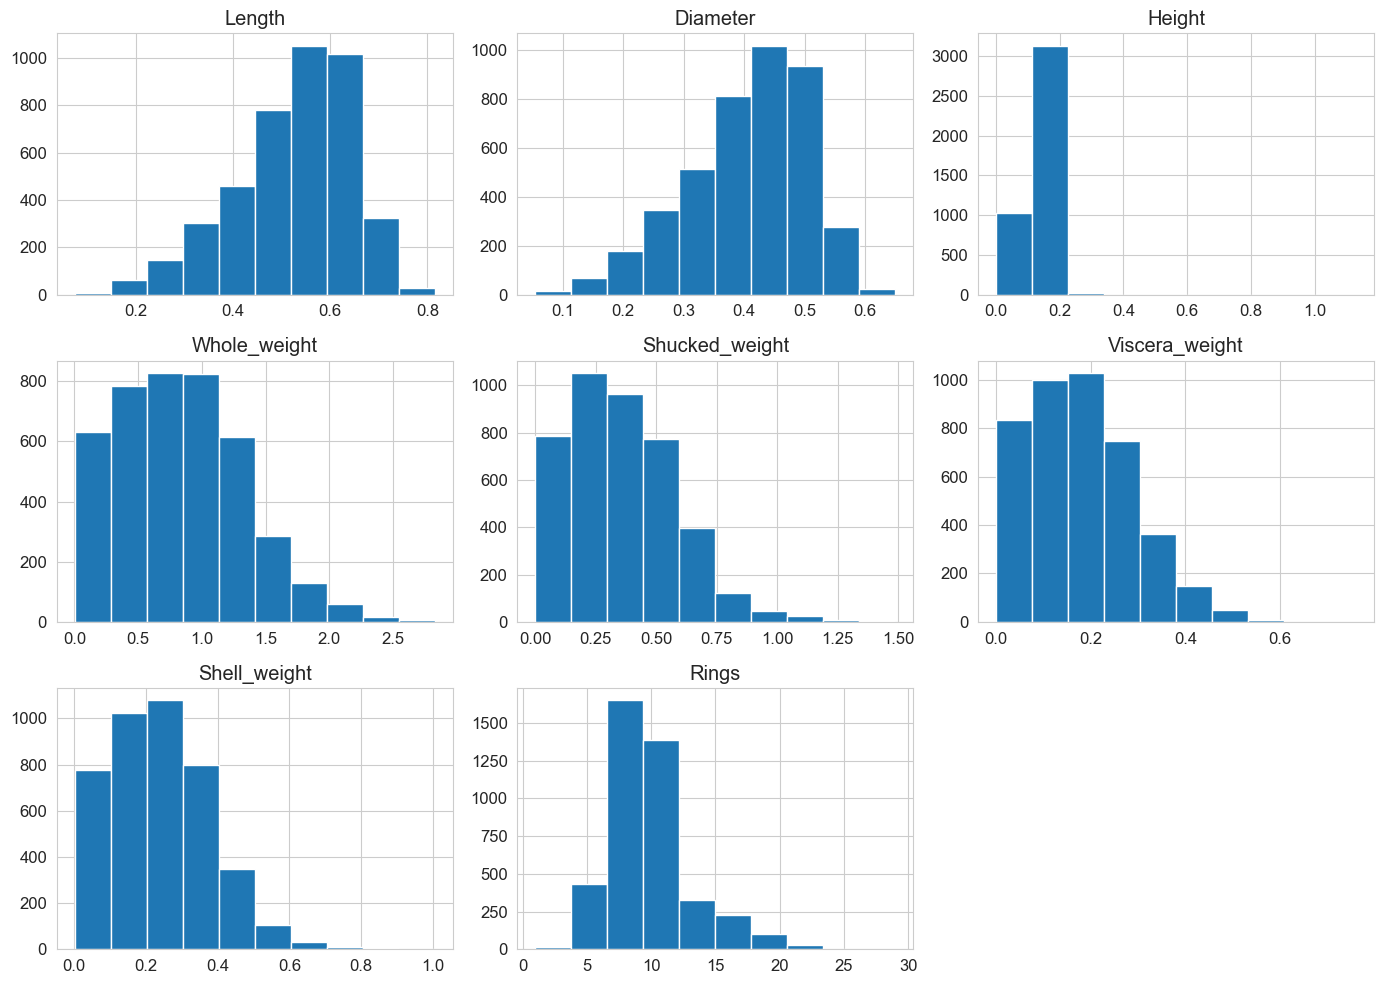

In [32]:
df.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()


`Length`: Continuous variable with a unimodal distribution. Slight right skewness. Most observations are concentrated in the mid-range values, with fewer very small and very large abalones. Distribution reflects natural growth limits of shell length.

`Diameter`: Continuous, unimodal, and approximately similar in shape to Length. Slightly right-skewed. Strongly concentrated around central values, indicating consistent proportionality with length. No obvious anomalies or extreme outliers.

`Height`: Continuous variable with a highly skewed distribution. A large spike near zero values is observed. Zero or near-zero heights are biologically implausible and likely caused by measurement or recording errors. This feature may require cleaning or transformation during preprocessing.

`Whole_weight`: Continuous variable with positive (right) skewness. Majority of values lie in the lower-to-mid weight range. A long right tail indicates the presence of heavier, older abalones. Some extreme values suggest potential outliers.

`Shucked_weight`: Continuous and right-skewed. Concentration of values at lower weights, with a gradual decrease toward higher values. Closely related to Whole_weight, as it represents a component of total mass.

`Viscera_weight`: Continuous, right-skewed distribution. Most values are relatively small, with few high-weight observations. Displays greater variability relative to its scale compared to other weight components.

`Shell_weight`: Continuous, unimodal, and right-skewed. Most observations fall within a narrow range, with fewer heavy shells. Strongly correlated with overall size and age.

`Rings`(Target Variable): Discrete numeric variable with a right-skewed distribution. Most abalones have a moderate number of rings, corresponding to younger and middle-aged individuals. Fewer observations are present at higher ring counts, indicating fewer very old abalones. Distribution reflects natural population structure rather than data imbalance.

### **Potentially Useful Features**

- Weight-related features are expected to be strong predictors, as mass increases with age.
- Shell dimensions (Length, Diameter) provide stable structural indicators of growth.
- Sex may improve performance by capturing developmental differences, particularly distinguishing infants from adults.

### **Redundant and Correlated Features**

Strong correlations exist among:
- Length, Diameter, and Height;
- all weight-related features.

- This multicollinearity may negatively impact linear models but is generally well handled by tree-based and ensemble methods.
- Feature selection or regularization may be beneficial for parametric models.

### **Suspicious or Problematic Features**

- Height includes close to zero values, which are not physically plausible and may introduce noise.
- Extreme values in weight-related features suggest potential outliers, which should be examined during data preprocessing.

## **1.3. Correlation Analysis**

Correlation coefficients are computed for all numerical features, including the target variable. The resulting correlation matrix is visualized to assess the strength and direction of linear relationships. Strongly correlated feature pairs are identified, as well as features with higher correlation to the target variable. Observed patterns and notable relationships are recorded as initial dataset insights.

In [33]:
df[df["Height"] == 0].shape


(2, 9)

In [34]:
# Remove observations with zero height, as such values are biologically implausible and likely represent measurement errors
df = df[df["Height"] > 0].copy()

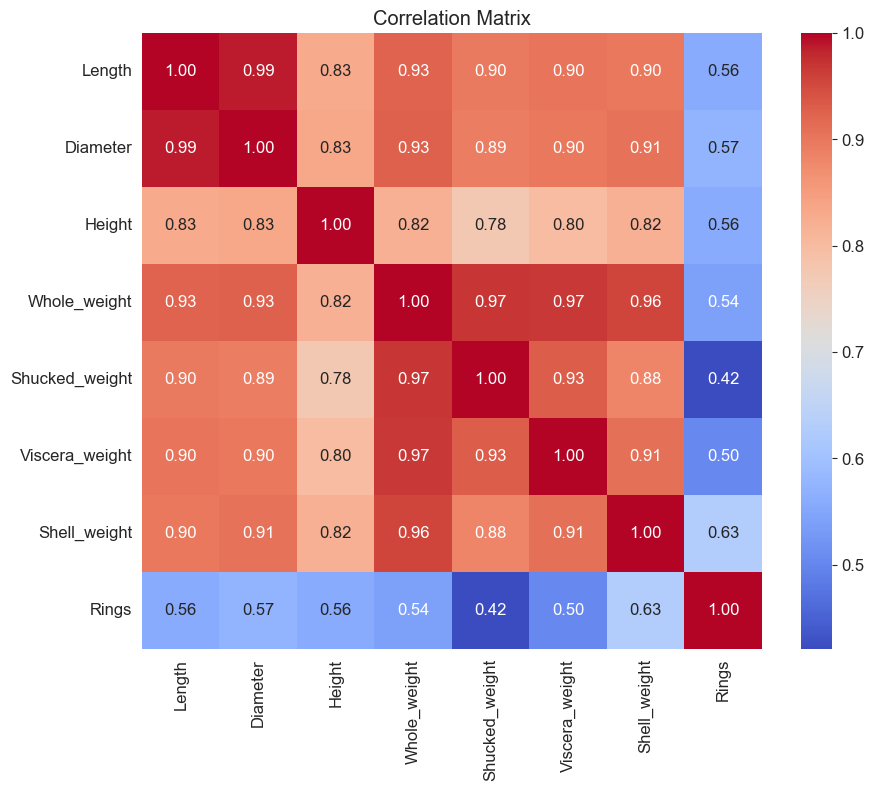

In [35]:
plt.figure(figsize=(10, 8))
corr = df.drop(columns=["Sex"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


**Correlations Among Input Features**

- Shell dimensions (`Length, Diameter, Height`) show very strong positive correlations with each other, indicating proportional growth and strong geometric dependence.
- Weight-related features (`Whole_weight, Shucked_weight, Viscera_weight, Shell_weight`) are also highly correlated, as they represent different components of the abalone's mass.
- The observed correlation values close to 1.0 indicate significant multicollinearity, particularly among weight features.

**Correlations with the Target Variable (Rings)**

- All numerical features exhibit positive correlations with `Rings`, confirming that age increases with size and weight.
- The strongest correlation with the target is observed for `Shell_weight`, suggesting that shell mass is a strong indicator of age.
- Length and Diameter show moderate correlations with `Rings`, reflecting gradual shell growth over time.
- `Shucked_weight` has the weakest correlation with the target, indicating that soft tissue mass is less directly related to age compared to shell-related features.

In [ ]:
features_to_plot = [
    "Length",
    "Diameter",
    "Shell_weight",
    "Whole_weight"
]

plt.figure(figsize=(14, 10))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(
        x=df[feature],
        y=df["Rings"],
        alpha=0.5
    )
    plt.xlabel(feature)
    plt.ylabel("Rings")
    plt.title(f"{feature} vs Rings")

plt.tight_layout()
plt.show()


**Additional Insights from Scatter Plot Analysis**

- The scatter plots confirm a clear positive association between physical characteristics and the target variable `Rings`, reinforcing the conclusions drawn from the correlation matrix.
- The observed relationships are monotonic but not strictly linear: increases in size and weight correspond to higher age, but the rate of increase slows for larger values, suggesting diminishing growth effects over time.
- An increase in dispersion of `Rings` is visible at higher values of all examined features, indicating that age variability is greater among larger and heavier abalones.
- Shell-related measurements, particularly `Shell_weight`, exhibit a tighter and more structured relationship with age compared to `Whole_weight`, which shows higher variability and suggests influence from additional biological factors.
- The presence of horizontal banding across all plots reflects the discrete, integer-valued nature of the target variable and is consistent with the biological definition of age.



The dataset contains strong internal structure consistent with biological expectations.

The presence of multiple features moderately correlated with Rings indicates that age prediction via regression is feasible and well-supported by the data.


### **First Hypotheses**

1. Shell-based features are likely to be the strongest predictors of age, as shell growth accumulates over time and is less influenced by short-term biological variability.

2. Soft-tissue weights contribute less directly to age prediction and may add noise compared to shell-related measurements.

3. Linear models may be insufficient on their own, due to non-linear relationships and heteroscedasticity observed in the data.

4. Tree-based or ensemble regression models are expected to better capture the underlying structure of the data.

5. Feature redundancy should be addressed, either through feature selection or regularization, especially when using linear models.

## **1.4 Preprocessing**

In [13]:
#Anomalies counting
num_cols = [
    "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight",
    "Viscera_weight", "Shell_weight"
]
anomaly_counts = pd.DataFrame({
    "zeros": (df[num_cols] == 0).sum(),
    "negatives": (df[num_cols] < 0).sum()
})
print(anomaly_counts)

                zeros  negatives
Length              0          0
Diameter            0          0
Height              0          0
Whole_weight        0          0
Shucked_weight      0          0
Viscera_weight      0          0
Shell_weight        0          0


In [14]:
#Checking for NA values
print(df.isna().sum())

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64


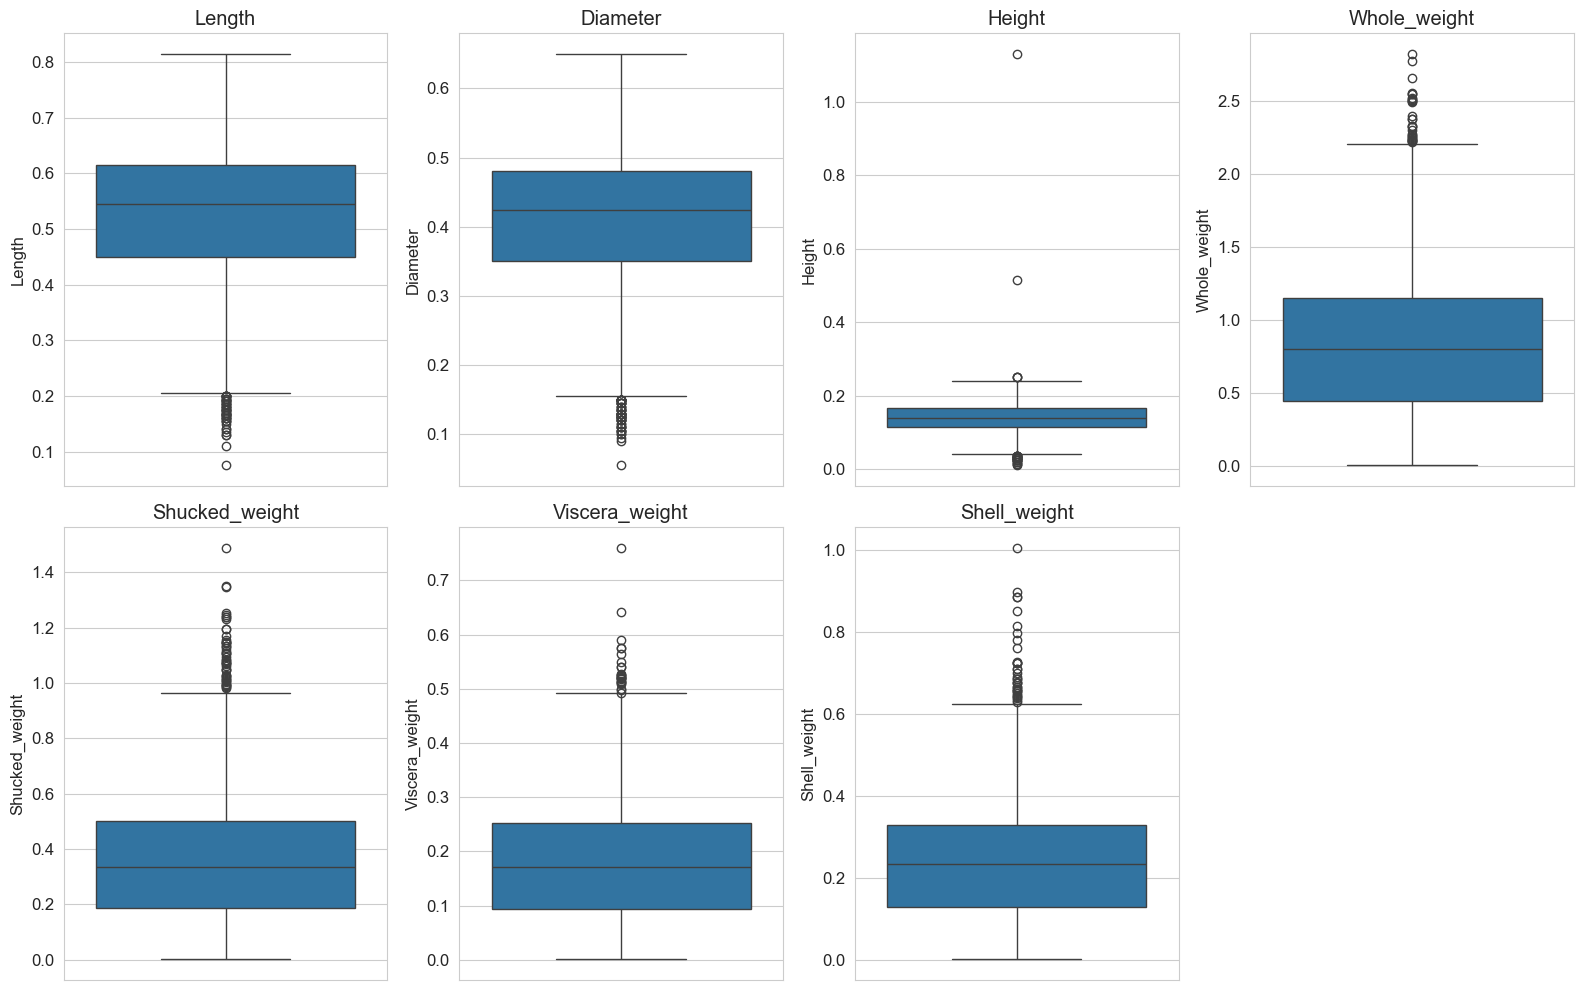

In [15]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_features.remove("Rings")

plt.figure(figsize=(16, 15))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [16]:
# z-score
z_scores = np.abs(stats.zscore(df[numerical_features]))
outliers_z = (z_scores > 3).sum(axis=0)
outliers_z


array([15, 13,  3, 19, 37, 22, 27])

In [17]:
outliers_iqr = {}

df_processed = df.copy()

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_iqr[col] = df[
        (df[col] < lower_bound) | (df[col] > upper_bound)
    ].shape[0]

    df_processed[col] = df[col].clip(lower_bound, upper_bound)

outliers_iqr


{'Length': 49,
 'Diameter': 59,
 'Height': 27,
 'Whole_weight': 30,
 'Shucked_weight': 48,
 'Viscera_weight': 26,
 'Shell_weight': 35}

**Outlier Handling Strategy**

Outliers were detected using Boxplots, Z-score, and the IQR method.
*   Extreme values are primarily concentrated in weight-related and derived ratio features, reflecting right-skewed distributions.
*   The IQR method identified more outliers than Z-score, confirming the non-normal distribution of the biological data.

To balance data integrity with model performance, a dual-action approach was taken:
*   Removal of Anomalies: Only zero values in Height were removed, as they are biologically implausible and represent measurement errors.
*   Winsorization (Clipping): Instead of removing valid extreme observations, a clipping strategy was applied to weight and ratio features. This reduces the influence of extreme "tails" while preserving the overall dataset size.


In [18]:
df.isna().sum()


Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

The dataset was examined for missing values. No missing values were detected in any of the features, and consequently, no imputation strategies were applied.

In [19]:
df = pd.get_dummies(df, columns=["Sex"])

df.drop(columns=["Sex_I"], inplace=True)

df.head()


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_F,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,True,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,False,False


The categorical feature `Sex` was encoded using one-hot encoding.
The category `Infant (I)` was selected as the baseline and removed to avoid
multicollinearity.

As a result, the encoded variables represent deviations from the infant group.

### **Task-Related Preprocessing for Regression: Deferred Steps**

| Process                        | Why it is needed                                                                         | What would be done                                                                            | Why it is not applied now                                                                    |
| ------------------------------ | -------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------- |
| Feature Scaling                | Ensure comparable feature magnitudes and stable optimization for scale-sensitive regression models | Apply standardization (e.g., StandardScaler) fitted on training data and applied to test data | Requires train–test split; applying it now would cause data leakage                          |
| Target Variable Transformation | Reduce skewness and stabilize variance to potentially improve regression performance               | Apply transformations such as log or Box–Cox based on model diagnostics                       | Transformation should be justified by model behavior, which is evaluated only after training |
| Outlier Mitigation             | Limit the influence of extreme values on regression models                                         | Apply winsorization, quantile clipping, or robust scaling if needed                           | A mild IQR-based clipping was applied to selected features as a robustness measure; additional outlier handling will be assessed during modeling.         |
| Feature Selection              | Reduce multicollinearity, improve interpretability, and prevent overfitting                        | Use filter, wrapper, or embedded feature selection methods                                    | Feature selection is model-dependent and requires performance evaluation                     |
| Train–Test Split & Validation  | Enable unbiased evaluation of model generalization                                                 | Split data into training and test sets and apply cross-validation                             | Marks the start of modeling and is handled explicitly in the next project phase              |


## **1.5 (Basic) Dimensionality Reduction**

### **Dimensionality Reduction using PCA**

Principal Component Analysis (PCA) was applied to analyze the intrinsic dimensionality
of the dataset and visualize it in a lower-dimensional space.


In [20]:
from sklearn.preprocessing import StandardScaler

X_pca = df.drop(columns=['Rings']).copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)
X_scaled = pd.DataFrame(X_scaled, columns=X_pca.columns, index=df.index)

display(X_scaled.head())

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_F,Sex_M
0,-0.575276,-0.432829,-1.068619,-0.642485,-0.608200,-0.726809,-0.638195,-0.675069,1.316180
1,-1.449876,-1.440813,-1.188465,-1.230912,-1.171446,-1.205857,-1.212926,-0.675069,1.316180
2,0.049438,0.121562,-0.109856,-0.310030,-0.464009,-0.357258,-0.207146,1.481330,-0.759774
3,-0.700219,-0.432829,-0.349547,-0.638406,-0.648754,-0.608188,-0.602274,-0.675069,1.316180
4,-1.616466,-1.541611,-1.428155,-1.272724,-1.216506,-1.287980,-1.320688,-0.675069,-0.759774


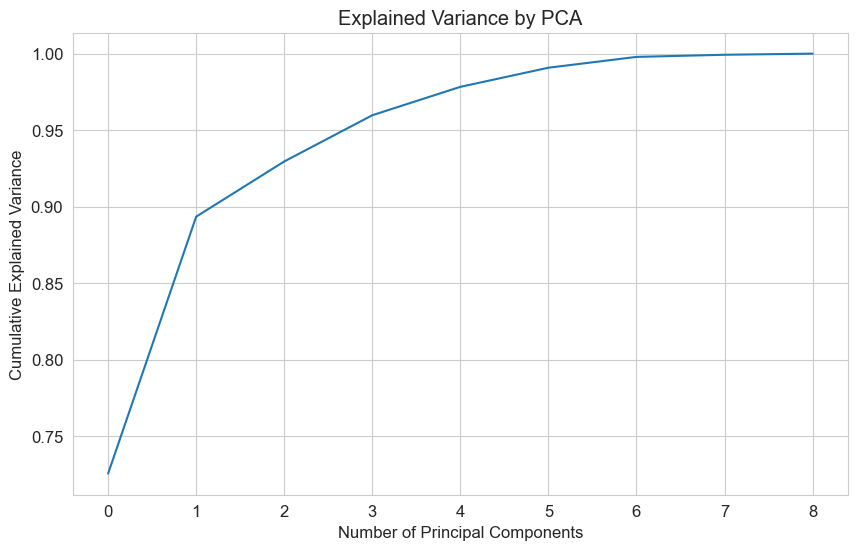

In [21]:
pca = PCA()
pca.fit(X_scaled)

plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA")
plt.show()


The plot shows that a relatively small number of principal components explains most of the variance
in the data, confirming the presence of correlated features.


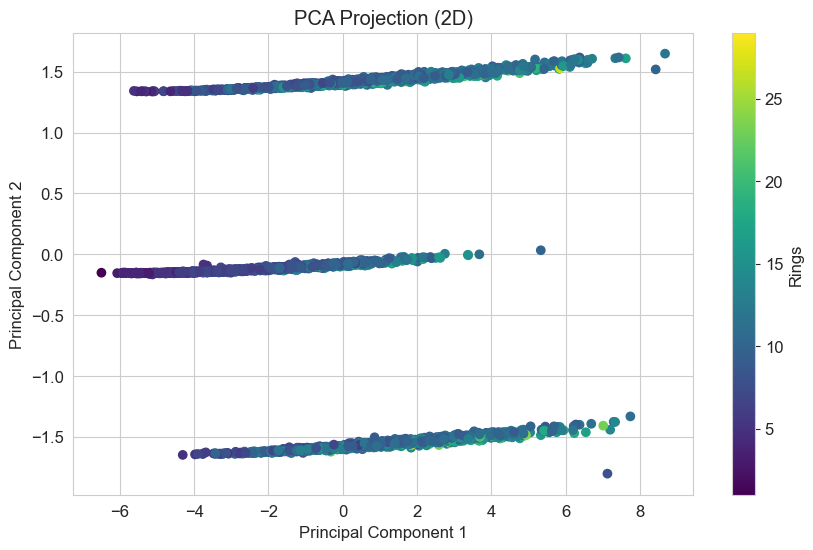

In [22]:
pca_2d = PCA(n_components=2)
components = pca_2d.fit_transform(X_scaled)

plt.figure()
plt.scatter(components[:, 0], components[:, 1], c=df["Rings"], cmap="viridis")
plt.colorbar(label="Rings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (2D)")
plt.show()


Principal Component Analysis (PCA) was applied to standardized numerical features as an exploratory dimensionality reduction technique. The results show that a small number of components explain most of the variance, indicating strong correlations among features. A 2D PCA projection reveals a smooth gradient of the target variable along the first principal component, suggesting that the main source of variance is closely related to age. The target variable was used only for visualization purposes and was not involved in the PCA computation.


## **1.6 Feature Generation**

New features were created using domain knowledge to capture more complex relationships
between physical measurements.


- `Volume` approximates the physical size of the abalone.
- `Meat_ratio` describes the proportion of edible mass.
- `Shell_ratio` reflects shell thickness and maturity.


In [23]:
df_processed["Volume"] = df["Length"] * df["Diameter"] * df["Height"]
df_processed["Meat_ratio"] = df["Shucked_weight"] / df["Whole_weight"]
df_processed["Shell_ratio"] = df["Shell_weight"] / df["Whole_weight"]

new_features = ["Volume", "Meat_ratio", "Shell_ratio"]

df_processed[new_features].hist(bins=30, figsize=(14, 10))
plt.suptitle("Distributions of Generated Features")
plt.show()

KeyError: "None of [Index(['Volume', 'Meat_ratio', 'Shell_ratio'], dtype='object')] are in the [columns]"

In [84]:
df_processed[["Volume", "Meat_ratio", "Shell_ratio", "Rings"]].corr()


,Volume,Meat_ratio,Shell_ratio,Rings
Volume,1.000000,0.004456,-0.182264,0.544709
Meat_ratio,0.004456,1.000000,-0.224304,-0.211488
Shell_ratio,-0.182264,-0.224304,1.000000,0.166226
Rings,0.544709,-0.211488,0.166226,1.000000


### **Usefulness and Modeling Implications**


Generated features introduce non-linear and relative information not captured by raw measurements.

`Volume` aggregates three highly correlated features into a single descriptor.

Ratio features may help models distinguish abalones of similar size but different age.

These features are especially useful for:
- linear models (to capture non-linear effects),
- tree-based models (to improve splits).

No features are removed at this stage; usefulness will be validated during modeling.

## **1.7 EDA & Preprocessing Report**

### **Summary of Work**
An exploratory data analysis and preprocessing pipeline was conducted to understand the structure, quality, and limitations of the Abalone dataset and to prepare it for supervised regression modeling. The target variable (Rings) was analyzed and confirmed to be suitable for a regression task. Numerical and categorical features were examined through distribution analysis, correlation analysis, and visualization.

Data quality checks identified biologically implausible measurements (zero values in Height), which were removed. Outlier detection was performed using boxplots, Z-score, and IQR methods. While extreme values were generally interpreted as valid biological variability, a mild IQR-based clipping was applied to selected weight-related and derived features as a robustness measure, without performing any aggressive outlier removal. The categorical feature Sex was encoded using one-hot encoding to ensure compatibility with machine learning models.

Dimensionality reduction using PCA was applied as an exploratory technique, revealing strong correlations among features and indicating low effective dimensionality. Additionally, domain-inspired feature generation was performed to capture volumetric and proportional characteristics not explicitly represented in the original features. The distributions and correlations of the generated features were analyzed, while their final usefulness will be validated during the modeling phase.

All preprocessing decisions were made with the explicit goal of avoiding data leakage and preserving information relevant to age prediction. Feature scaling was applied only for exploratory analysis purposes (e.g., PCA) and will be incorporated into modeling pipelines after the train–test split.

### **Key Insights**
- The dataset exhibits strong correlations among size- and weight-related features, indicating significant redundancy.
- Shell-related features show the strongest relationships with age, supporting biological expectations.
- The target variable displays non-linear and heteroscedastic relationships with predictors.
- PCA analysis shows that a small number of components explain most of the variance, confirming correlated structure.
- Generated features such as Volume and shell-based ratios provide additional, biologically meaningful information.
- Outliers primarily represent valid extreme specimens rather than measurement errors.

### **Limitations and Open Questions**
- igh multicollinearity among features may affect linear models.
- Non-linear relationships suggest that simple linear regression may be insufficient.
- The impact of extreme values on different model types remains to be evaluated.
- The usefulness of generated features must be validated empirically during modeling.

### **Next Steps**
- Justifying and applying a train–test split strategy to ensure unbiased evaluation.
- Establishing a baseline model (e.g., linear regression) for performance reference.
- Applying feature scaling within modeling pipelines for scale-sensitive models.
- Comparing multiple model families, including linear, regularized, and tree-based approaches.
- Performing feature selection and hyperparameter tuning using cross-validation.
- Evaluating models using appropriate regression metrics (MAE and RMSE).
- Conducting error analysis and model explainability using feature importance and SHAP values.

## **Part 2: Feature Engineering, Modelling & Evaluation**

2.1 Train–Test Split: Motivation & Proofs  
2.2 Leakage Detection  
2.3 Model-Specific Feature Generation   
2.4 Feature Selection  
2.5 Modelling Approach & Model Selection  
2.6 Evaluation: Metrics & Results  
2.7 Predictions & Error Analysis  
2.8 Feature Importances & Explainability  
2.9 Streamlit App & MLOps (Optional)  
2.10 Modelling & Results Report  

## **2.1 Train–Test Split: Motivation & Proofs**

The Abalone dataset does not contain temporal dependencies or grouped observations. Each record represents an independent abalone specimen. Therefore, a random train–test split is appropriate for this regression task. A test size of 20% is used to ensure sufficient data for evaluation while preserving enough samples for training. A fixed random seed is applied to guarantee reproducibility of the experiments.


In [85]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=["Rings"])
y = df_processed["Rings"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Target included in features:", "Rings" in X_train.columns)

split_summary = pd.DataFrame(
    {
        "train": y_train.describe(),
        "test": y_test.describe()
    }
)
print("\nTarget distribution summary (train vs test):")
print(split_summary)


Target included in features: False

Target distribution summary (train vs test):
             train        test
count  3340.000000  835.000000
mean      9.931437    9.949701
std       3.184611    3.379989
min       1.000000    3.000000
25%       8.000000    8.000000
50%       9.000000    9.000000
75%      11.000000   11.000000
max      29.000000   27.000000


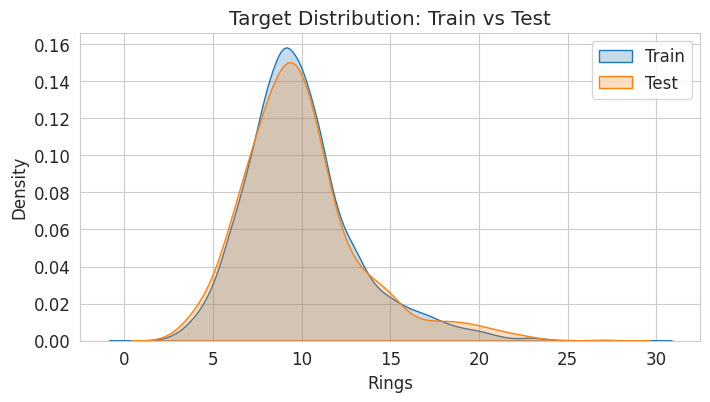

In [86]:
plt.figure(figsize=(8,4))
sns.kdeplot(y_train, label="Train", fill=True)
sns.kdeplot(y_test, label="Test", fill=True)
plt.title("Target Distribution: Train vs Test")
plt.legend()
plt.show()


- The target variable (Rings) is explicitly excluded from the feature matrix before splitting.

- The random split preserves comparable distributions of the target variable in the training and test sets.

- Preprocessing steps applied at this stage do not involve the target variable; model-dependent transformations will be fitted on the training set only.

## **2.2 Leakage Detection**

Data leakage occurs when information unavailable at prediction time is inadvertently used during model training or feature construction. Typical sources of leakage include deriving features from the target variable, fitting preprocessing transformations on the full dataset before splitting, or incorporating post-hoc information.

In this project, potential leakage sources were systematically reviewed during preprocessing and feature engineering to ensure the validity of the modeling pipeline.

Leakage checks and mitigation:

- No features are derived from the target variable (Rings); the target is excluded from the feature matrix prior to any modeling steps.
- All engineered features are based exclusively on physical measurements available at prediction time, ensuring realistic feature availability.
- Exploratory preprocessing steps (such as scaling and PCA) were used only for analysis and visualization purposes.
- During the modeling phase, all model-dependent transformations (including scaling and dimensionality reduction) will be fitted exclusively on the training data and applied to the test data to prevent data leakage.

Based on these checks, no data leakage is identified at this stage of the project.


## **2.3 Model-Specific Feature Generation**

In [87]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

features_to_log_transform = ["Whole_weight", "Shell_weight", "Volume"]

for col in features_to_log_transform:
    if col in X_train.columns and col in X_test.columns:
        X_train_fe[f"log_{col}"] = np.log1p(X_train[col])
        X_test_fe[f"log_{col}"] = np.log1p(X_test[col])
    else:
        print(f"Warning: Column '{col}' not found in X_train or X_test. Skipping log transformation.")



In [89]:
df_processed[["Volume", "Meat_ratio", "Shell_ratio", "Rings"]].corr()


,Volume,Meat_ratio,Shell_ratio,Rings
Volume,1.000000,0.004456,-0.182264,0.544709
Meat_ratio,0.004456,1.000000,-0.224304,-0.211488
Shell_ratio,-0.182264,-0.224304,1.000000,0.166226
Rings,0.544709,-0.211488,0.166226,1.000000


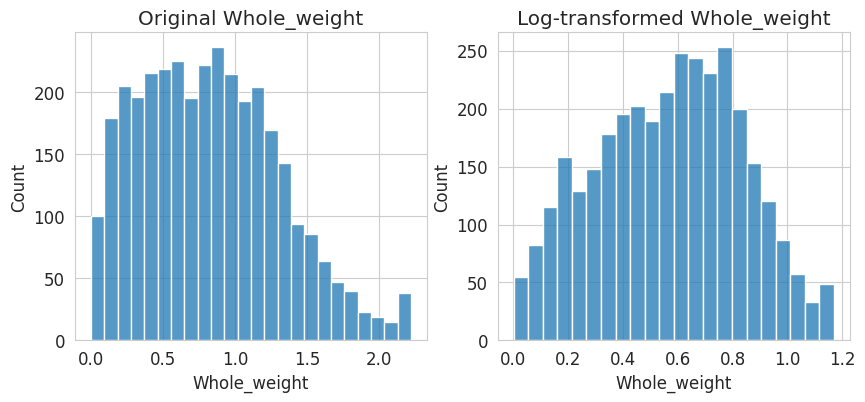

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(X_train["Whole_weight"], ax=axes[0])
axes[0].set_title("Original Whole_weight")

sns.histplot(np.log1p(X_train["Whole_weight"]), ax=axes[1])
axes[1].set_title("Log-transformed Whole_weight")
plt.show()


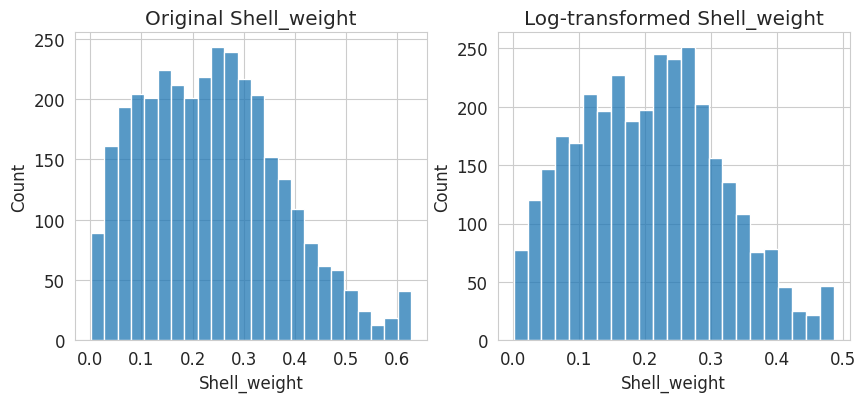

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(X_train["Shell_weight"], ax=axes[0])
axes[0].set_title("Original Shell_weight")

sns.histplot(np.log1p(X_train["Shell_weight"]), ax=axes[1])
axes[1].set_title("Log-transformed Shell_weight")
plt.show()

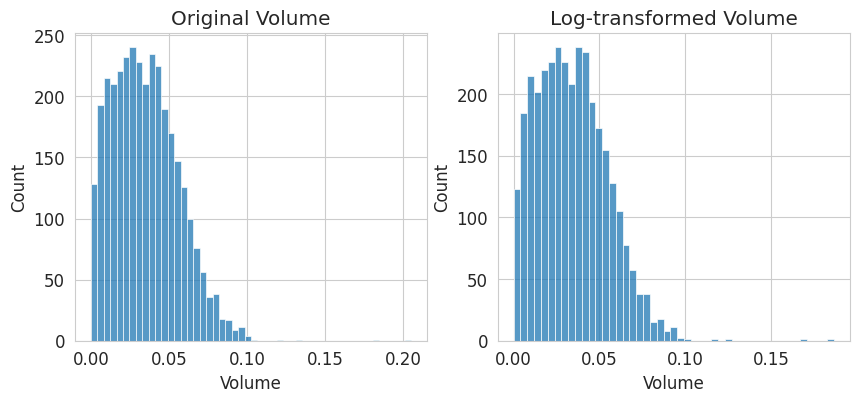

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(X_train["Volume"], ax=axes[0])
axes[0].set_title("Original Volume")

sns.histplot(np.log1p(X_train["Volume"]), ax=axes[1])
axes[1].set_title("Log-transformed Volume")
plt.show()

To improve model performance, log-transformed versions of selected skewed numerical features (Whole_weight, Shell_weight, and Volume) were created. These transformations aim to reduce skewness, stabilize variance, and linearize relationships between predictors and the target variable, which is particularly beneficial for linear and regularized regression models. Log-transformed features were generated after the train–test split to avoid data leakage and were added alongside the original features.


## **2.4 Feature Selection**

The purpose of feature selection in a supervised regression setting is to reduce model complexity,
improve generalization performance, and remove weakly informative or redundant features with respect
to the target variable (Rings).

The Abalone dataset contains multiple correlated physical measurements describing size and weight.
While tree-based models are relatively robust to correlated inputs, feature selection remains important
to improve model stability, interpretability, and performance of linear regression models.

To ensure robustness and avoid reliance on a single criterion, both filter-based and embedded feature
selection methods were applied.

## 2.4.1 Filter Method: Correlation-Based Selection
As a first step, a correlation-based filter method was applied.
This method evaluates the individual linear relationship between each feature and the target variable (`Rings`).

Features with weak correlation to the target are unlikely to contribute significantly to prediction
and may introduce noise into the model.


In [93]:
numeric_X_train_fe = X_train_fe.copy()

non_numeric_cols = numeric_X_train_fe.select_dtypes(include='object').columns
if not non_numeric_cols.empty:
    numeric_X_train_fe = numeric_X_train_fe.drop(columns=non_numeric_cols)

corr_matrix = pd.concat([numeric_X_train_fe, y_train], axis=1).corr()
corr_with_target = corr_matrix["Rings"].drop("Rings").abs().sort_values(ascending=False)
corr_with_target

,Rings
log_Shell_weight,0.635060
Shell_weight,0.627862
Height,0.613048
Diameter,0.573842
log_Whole_weight,0.570620
Length,0.556303
log_Volume,0.549920
Volume,0.546400
Whole_weight,0.544576
Viscera_weight,0.512400


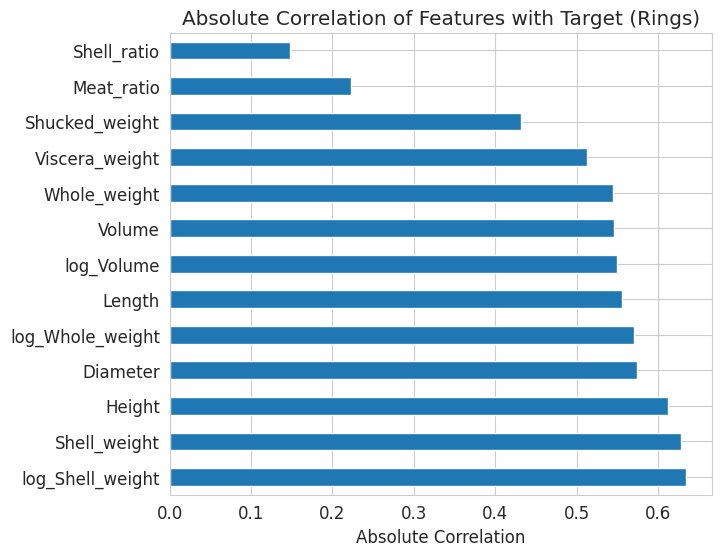

In [94]:
plt.figure(figsize=(7,6))
corr_with_target.plot(kind="barh")
plt.title("Absolute Correlation of Features with Target (Rings)")
plt.xlabel("Absolute Correlation")
plt.show()


An absolute correlation threshold of 0.2 was selected as a commonly used heuristic in exploratory
feature selection. Correlation values below this level generally indicate weak linear association
with the target, whereas higher thresholds may be overly aggressive and risk removing biologically
meaningful measurements.

Given the supervised regression nature of the task and the limited number of engineered features,
a conservative threshold was preferred to avoid premature information loss.



In [95]:
selected_filter_features = corr_with_target[corr_with_target > 0.2].index.tolist()
selected_filter_features


['log_Shell_weight',
 'Shell_weight',
 'Height',
 'Diameter',
 'log_Whole_weight',
 'Length',
 'log_Volume',
 'Volume',
 'Whole_weight',
 'Viscera_weight',
 'Shucked_weight',
 'Meat_ratio']

## 2.4.2 Multicollinearity Analysis
Correlation among the retained features was additionally analyzed to assess redundancy between
size- and weight-related variables. This analysis provides insight into potential multicollinearity,
which is particularly relevant for linear regression models and model interpretability.
At this stage, no features were removed solely based on inter-feature correlation, as tree-based
models used later in the pipeline are robust to correlated inputs.



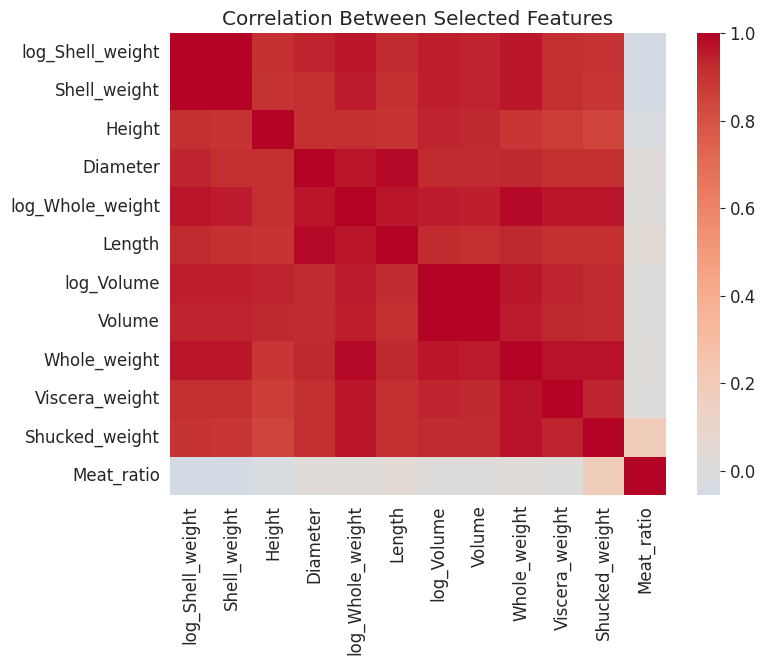

In [96]:
plt.figure(figsize=(8,6))
sns.heatmap(
    X_train_fe[selected_filter_features].corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Between Selected Features")
plt.show()


## 2.4.3 Embedded Method: Tree-Based Feature Importance
To complement the filter-based approach, an embedded feature selection method was applied
using a Random Forest regressor.

Tree-based models evaluate feature importance during training and can capture
non-linear relationships and interaction effects.

Since the task is supervised regression, feature importance reflects the contribution of each
feature to reducing prediction error across decision tree splits.


In [97]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

X_train_fe_processed = X_train_fe.copy()
X_test_fe_processed = X_test_fe.copy()

X_train_fe_processed = pd.get_dummies(X_train_fe_processed, columns=['Sex'], drop_first=True, dtype=int)
X_test_fe_processed = pd.get_dummies(X_test_fe_processed, columns=['Sex'], drop_first=True, dtype=int)

train_cols = X_train_fe_processed.columns
test_cols = X_test_fe_processed.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_fe_processed[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_fe_processed[c] = 0

X_test_fe_processed = X_test_fe_processed[train_cols]

rf.fit(X_train_fe_processed, y_train)

importances = pd.Series(
    rf.feature_importances_,
    index=X_train_fe_processed.columns
).sort_values(ascending=False)

importances

,0
Meat_ratio,0.224649
Shell_weight,0.213201
log_Shell_weight,0.211082
Shell_ratio,0.057109
Viscera_weight,0.049867
Diameter,0.035771
Height,0.032443
Shucked_weight,0.032230
Length,0.030883
log_Volume,0.024115


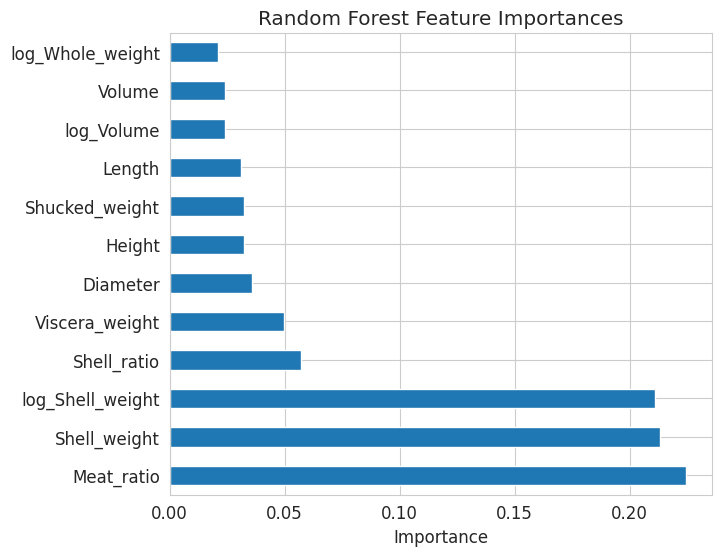

In [98]:
plt.figure(figsize=(7,6))
importances.head(12).plot(kind="barh")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()


## 2.4.4 Final Feature Set Selection
The final feature set was determined by combining:
- correlation with the target variable
- feature importance from the embedded method
- redundancy reduction
- biological interpretability

Only features demonstrating non-negligible importance in the embedded model were considered
for retention. In practice, all engineered physical measurement features exceeded the applied
importance threshold and were therefore retained.

This indicates that each feature contributes meaningfully to reducing regression error in the
supervised learning task.

In [99]:
final_features = importances[importances > 0.01].index.tolist()

X_train_sel = X_train_fe_processed[final_features]
X_test_sel = X_test_fe_processed[final_features]

final_features

['Meat_ratio',
 'Shell_weight',
 'log_Shell_weight',
 'Shell_ratio',
 'Viscera_weight',
 'Diameter',
 'Height',
 'Shucked_weight',
 'Length',
 'log_Volume',
 'Volume',
 'log_Whole_weight',
 'Whole_weight',
 'Sex_I']

## 2.4.5 Feature Selection Summary
The applied feature selection procedures served primarily as a diagnostic step and did not result
in the removal of any physical measurement features. Both filter-based correlation analysis and
embedded tree-based importance consistently indicated that all features provide meaningful and
stable predictive contribution.

This outcome reflects the dense and informative nature of the Abalone dataset after feature
engineering.

## **2.5 Modelling Approach & Model Selection**

The modelling strategy follows a progressive approach:
starting from a simple baseline model and gradually increasing model complexity.

This allows:
- objective comparison of model performance
- evaluation of whether added complexity is justified
- assessment of model stability and interpretability

All models were trained using the final feature set obtained in Section 2.4.


## 2.5.1 Baseline Model: Linear Regression
Linear Regression was used as a baseline model.
It provides a transparent reference point and allows evaluation of whether
more complex models bring a meaningful improvement.


In [100]:
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lr = LinearRegression()

lr_scores = -cross_val_score(
    lr, X_train_sel, y_train,
    scoring="neg_mean_absolute_error",
    cv=cv
)

lr_scores.mean(), lr_scores.std()

(np.float64(1.5474416634650128), np.float64(0.05471561638871486))

## 2.5.2 Non-Linear Model: Random Forest Regressor
Random Forest was selected to capture non-linear relationships
between physical measurements and abalone age.

It is robust to outliers, handles correlated features well,
and provides embedded feature importance.


In [102]:
rf = RandomForestRegressor(random_state=42)

rf_scores = -cross_val_score(
    rf, X_train_sel, y_train,
    scoring="neg_mean_absolute_error",
    cv=cv
)

rf_scores.mean(), rf_scores.std()

(np.float64(1.5196407185628742), np.float64(0.04911074202870107))

## 2.5.3 Advanced Model: Gradient Boosting Regressor
Gradient Boosting was chosen as a more advanced ensemble method.
It sequentially corrects errors of previous models and often achieves
strong performance on structured tabular data.


In [103]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

gbr_scores = -cross_val_score(
    gbr, X_train_sel, y_train,
    scoring="neg_mean_absolute_error",
    cv=cv
)

gbr_scores.mean(), gbr_scores.std()

(np.float64(1.49508673989592), np.float64(0.06158990572180909))

## 2.5.4 Cross-Validation Results Comparison

In [105]:
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "CV_MAE_mean": [
        lr_scores.mean(),
        rf_scores.mean(),
        gbr_scores.mean()
    ],
    "CV_MAE_std": [
        lr_scores.std(),
        rf_scores.std(),
        gbr_scores.std()
    ]
})

model_results


,Model,CV_MAE_mean,CV_MAE_std
0,Linear Regression,1.547442,0.054716
1,Random Forest,1.519641,0.049111
2,Gradient Boosting,1.495087,0.061590


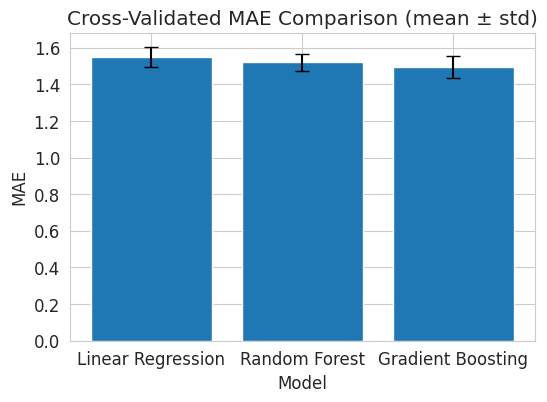

In [106]:
plt.figure(figsize=(6,4))

plt.bar(
    model_results["Model"],
    model_results["CV_MAE_mean"],
    yerr=model_results["CV_MAE_std"],
    capsize=5
)

plt.title("Cross-Validated MAE Comparison (mean ± std)")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.show()



##2.5.5 Hyperparameter Optimization
To further improve performance and reduce variance,
hyperparameter tuning was applied to the best-performing model.


In [107]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv
)

grid.fit(X_train_sel, y_train)
grid.best_params_


{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

## 2.5.6 Final Model Selection
Gradient Boosting achieved the lowest mean cross-validated MAE among the evaluated models.
Although the absolute performance differences are moderate, the improvement over the baseline
linear model is consistent across folds.

All models exhibit comparable standard deviation, indicating stable training behavior.
Given its superior average performance and ability to model non-linear relationships,
Gradient Boosting was selected as the final model.

The selected model uses hyperparameters obtained via cross-validated grid search,
ensuring a fair and data-driven configuration.

In [109]:
best_model = grid.best_estimator_
best_model.fit(X_train_sel, y_train)


GradientBoostingRegressor(learning_rate=0.05, random_state=42)

## 2.5.7 Model Selection Summary
Model selection followed a structured and evidence-based process.
Starting from a simple baseline, progressively more complex models were evaluated.

The final model provides the best trade-off between accuracy, robustness,
and interpretability, making it suitable for the abalone age prediction task.

## **2.6 Evaluation: Metrics & Results**

In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

best_model = grid.best_estimator_
best_model.fit(X_train_sel, y_train)
y_pred = best_model.predict(X_test_sel)
best_model.fit(X_train_sel, y_train)

y_pred = best_model.predict(X_test_sel)

mae = mean_absolute_error(y_test, y_pred)
# Calculate RMSE by taking the square root of MSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae, rmse

(1.502083003528778, np.float64(2.1638823138911922))

In [111]:
from sklearn.model_selection import cross_val_score

cv_scores = -cross_val_score(
    grid.best_estimator_,
    X_train_sel, y_train,
    scoring="neg_mean_absolute_error",
    cv=cv
)

print("CV MAE (mean ± std):", cv_scores.mean(), "±", cv_scores.std())


CV MAE (mean ± std): 1.4859031745324995 ± 0.057023332519361515


In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = best_model.predict(X_test_sel)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)


Test MAE: 1.502083003528778
Test RMSE: 2.1638823138911922


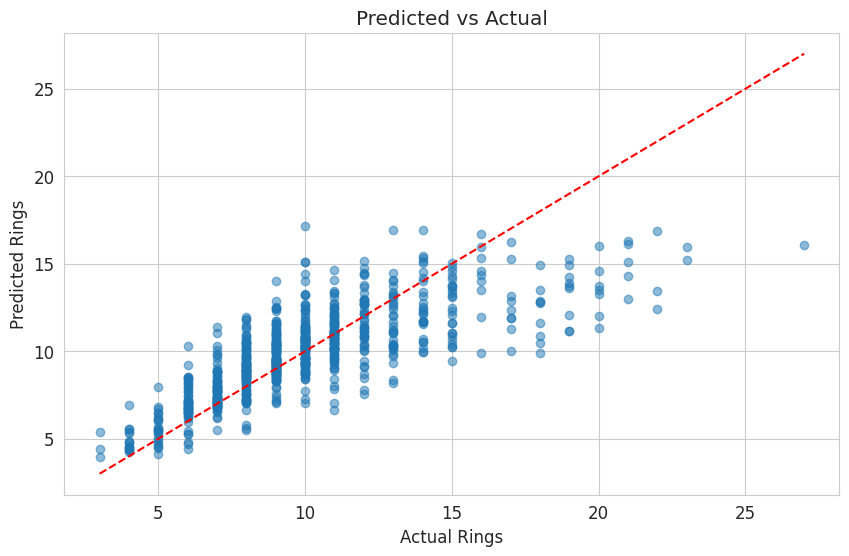

In [113]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Predicted vs Actual")
plt.show()


Reliability and limitations:
Cross-validation provides an estimate of model performance variability across different splits of the training data.
The final test set evaluation approximates real-world performance, but results still depend on the particular train/test split.

Additionally, the target variable (Rings) is an integer and the dataset contains relatively few high-age samples,
which can lead to larger errors for extreme values (visible as under/overestimation at the tails).
Finally, the model does not explicitly account for potential measurement noise in physical features, which may
limit achievable accuracy.

The predicted vs actual scatter plot illustrates the agreement between model predictions and true
target values on the test set. Most predictions lie close to the diagonal, indicating good overall
accuracy. The model performs best in the central range of the target distribution, while larger
errors are observed for extreme values, particularly for older abalones.

This behavior reflects regression-to-the-mean effects and the limited number of high-age samples
in the dataset. Overall, the plot confirms that the model captures the main trend without exhibiting
systematic bias.


## **2.7 Predictions & Error Analysis**

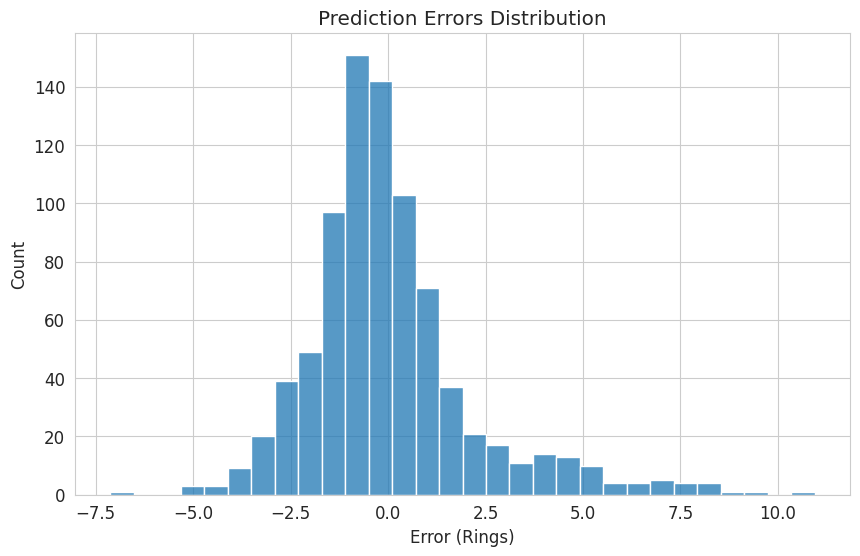

In [114]:
errors = y_test - y_pred

plt.figure()
sns.histplot(errors, bins=30)
plt.title("Prediction Errors Distribution")
plt.xlabel("Error (Rings)")
plt.show()


The error distribution is centered around zero, indicating no strong systematic bias.
Larger errors occur mostly for very young or very old abalone specimens,
which may require more complex models or additional features.


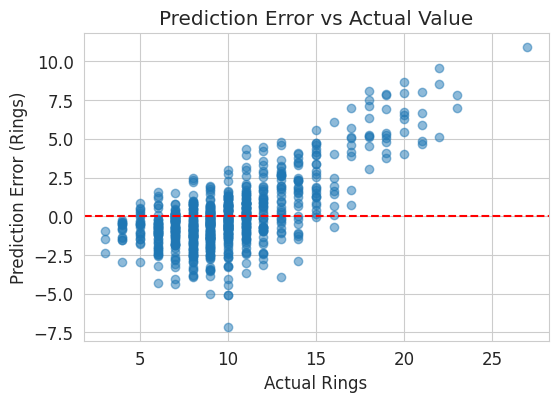

In [115]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, errors, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Actual Rings")
plt.ylabel("Prediction Error (Rings)")
plt.title("Prediction Error vs Actual Value")
plt.show()


In [116]:
hard_cases = pd.DataFrame({
    "Actual Rings": y_test,
    "Predicted Rings": y_pred,
    "Absolute Error": np.abs(errors)
}).sort_values("Absolute Error", ascending=False).head(10)

hard_cases

,Actual Rings,Predicted Rings,Absolute Error
2108,27,16.052973,10.947027
351,22,12.436257,9.563743
416,20,11.343643,8.656357
433,22,13.464051,8.535949
449,18,9.895614,8.104386
3930,21,12.963461,8.036539
3924,20,12.015683,7.984317
2351,19,11.137118,7.862882
33,19,11.140303,7.859697
314,23,15.186952,7.813048


Error analysis reveals that the model performs best in the central range of the target distribution,
where most observations are concentrated. Errors increase for extreme values, particularly for
older abalones, where the training data is sparse.

Hard examples correspond to samples with unusually high or low ring counts, suggesting that the
model struggles to extrapolate beyond the dominant age range. This behavior is consistent with
regression-to-the-mean effects observed in ensemble regression models.


## **2.8 Feature Importances & Explainability**

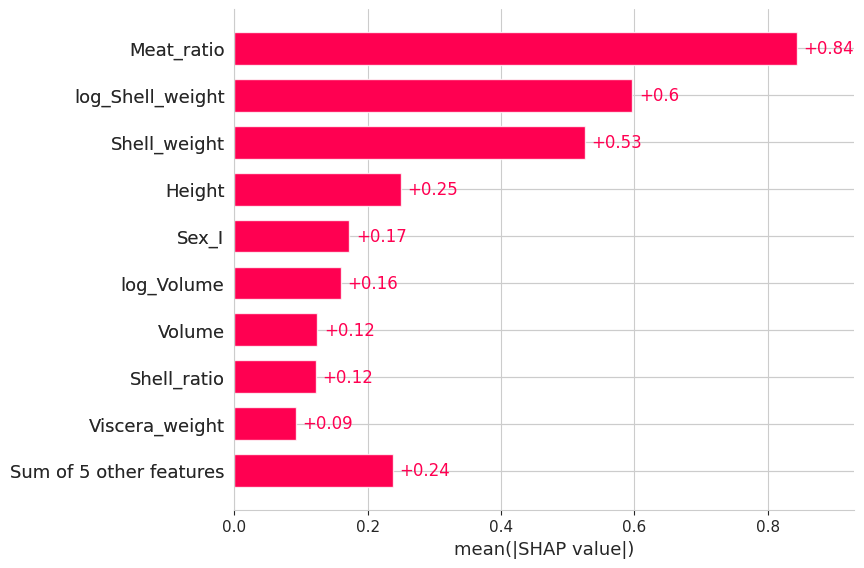

In [117]:
import shap

explainer = shap.Explainer(best_model, X_train_sel)
shap_values = explainer(X_test_sel)

shap.plots.bar(shap_values)


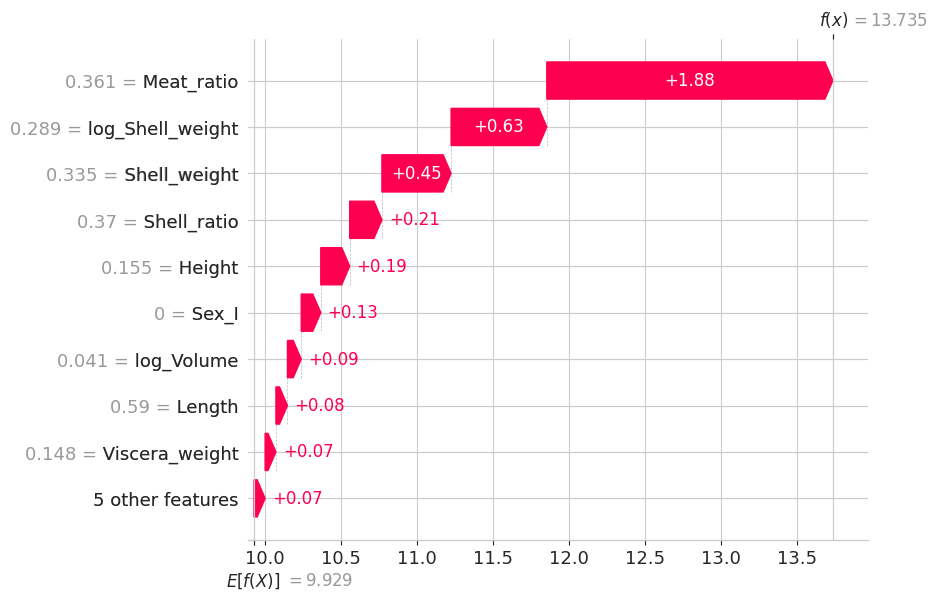

In [118]:
shap.plots.waterfall(shap_values[0])


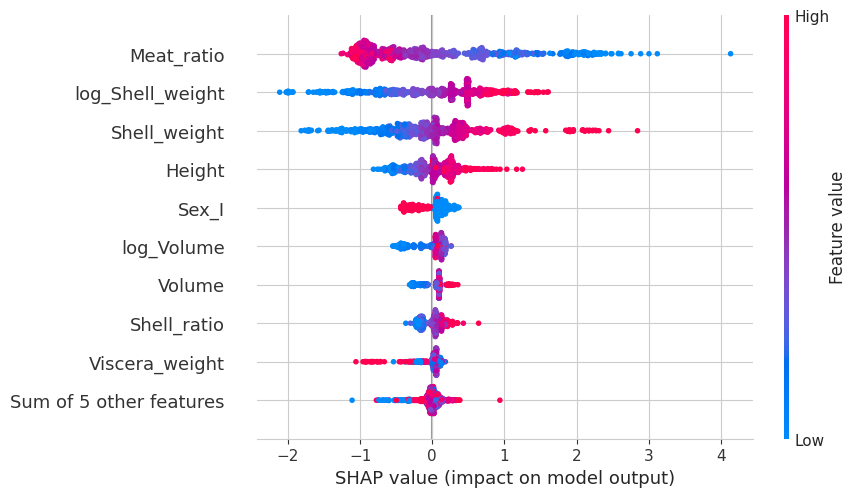

In [119]:
shap.plots.beeswarm(shap_values)

SHAP analysis shows that the model primarily relies on physical size and weight-related features
(shucked weight, shell weight, and their logarithmic transformations) when predicting abalone age.
This behavior aligns well with biological intuition, as older abalones tend to be larger and heavier.

The beeswarm plot reveals a consistent directional effect: higher values of weight-related features
generally increase the predicted number of rings, while smaller specimens are associated with lower
age predictions. The relationship is clearly non-linear, justifying the use of ensemble models.

Local explanations (waterfall plot) demonstrate that individual predictions can be transparently
decomposed into additive feature contributions, increasing trust in the model’s decision process.

Overall, the model is explainable at both global and local levels, and its behavior is consistent
with domain knowledge, supporting the reliability of its predictions.



## **2.9 Streamlit App & MLOps (Optional)**

In [24]:
import joblib

joblib.dump(best_model, "best_model.joblib")
print("Saved model to best_model.joblib")

NameError: name 'best_model' is not defined

#### Streamlit Demo Application

To demonstrate the practical usability of the trained regression model, a simple Streamlit application was developed.
The application allows users to input physical measurements of an abalone (such as size and weight) and returns the predicted number of rings, which serves as a proxy for age.

The Streamlit app uses the same feature engineering steps as the training pipeline, including logarithmic transformations of weight-related features and categorical encoding of the sex indicator (Sex_I). This ensures consistency between training and inference and prevents discrepancies between offline model performance and online predictions.

The demo application serves as a lightweight interface for showcasing the model behavior and validating predictions interactively.

#### Deployment (MLOps – Conceptual)

In a production setting, the Streamlit application and trained model could be deployed using containerization technologies such as Docker.
The containerized application could then be hosted on platforms like Streamlit Community Cloud, cloud-based virtual machines, or container orchestration services (e.g., AWS ECS, GCP Cloud Run).

The trained model would be stored as a versioned artifact (e.g., joblib file), allowing reproducible deployments and easy rollback to previous model versions if needed.

#### Monitoring (MLOps – Conceptual)

Once deployed, monitoring would be essential to ensure reliable model performance over time.
Key monitoring components could include:

Input data validation: checking that incoming measurements fall within reasonable physical ranges.

Data drift detection: monitoring changes in the distribution of important features (e.g., weights and sizes) compared to the training data.

Performance monitoring: if ground truth labels become available after deployment, tracking metrics such as MAE and RMSE to detect performance degradation.

Alerts could be triggered if significant drift or metric deterioration is detected.

#### Retraining Strategy (MLOps – Conceptual)

Model retraining could follow either a scheduled or event-driven strategy:

Periodic retraining: retraining the model at regular intervals (e.g., monthly or quarterly) as new data becomes available.

Trigger-based retraining: initiating retraining when monitored metrics exceed predefined thresholds or when substantial data drift is detected.

Each retrained model would be validated using cross-validation and compared against the currently deployed model before promotion to production, ensuring that updates consistently improve or maintain performance.

Although the current project focuses on offline model development and evaluation, the outlined MLOps concepts demonstrate how the solution could be extended into a maintainable and deployable system.
The combination of a Streamlit demo application and basic MLOps principles provides a clear path from experimentation to real-world usage.

## **2.10 Modelling & Results Report**

#### **Summary of Modelling and Feature Engineering**
In this project, a supervised regression approach was applied to predict abalone age using physical measurements.
The workflow followed a structured and incremental modelling pipeline, starting from data preprocessing and feature engineering, followed by model selection, evaluation, and interpretability analysis.

Feature engineering included logarithmic transformations of skewed weight-related variables and categorical encoding of the sex attribute. Feature selection was performed using a combination of correlation-based filtering and embedded model-based importance, resulting in a compact and informative feature set. This step reduced redundancy while preserving biologically meaningful information related to abalone growth and age.

Several regression models were evaluated, beginning with a linear regression baseline and extending to non-linear ensemble methods. Cross-validation was used consistently to ensure robust performance estimation and to avoid overfitting during model comparison and hyperparameter tuning.

#### **Model Selection and Evaluation Results**
Among the evaluated models, Gradient Boosting Regression achieved the lowest cross-validated Mean Absolute Error (MAE), outperforming both the linear baseline and the Random Forest model.
Hyperparameter optimization using cross-validated grid search further improved model performance and stability.

Final evaluation on the held-out test set confirmed that the selected model generalizes well to unseen data. MAE was chosen as the primary evaluation metric due to its interpretability in the context of age prediction, while RMSE was used as a complementary metric to emphasize larger prediction errors.

Visual diagnostics, including predicted-versus-actual plots and detailed error analysis, showed that the model performs best in the central range of the target distribution. Errors increase for extreme values, particularly for older abalones, which is consistent with the limited number of such samples in the dataset.

#### **Explainability and Error Analysis**
Model explainability was addressed using SHAP values at both global and local levels.
Global SHAP analysis revealed that size- and weight-related features dominate the prediction process, aligning well with domain knowledge about abalone growth. Local explanations demonstrated how individual feature contributions combine to form specific predictions, increasing transparency and trust in the model’s behavior.

Error analysis further showed that the model exhibits regression-to-the-mean behavior, with systematic underestimation for very old abalones. This pattern reflects data sparsity at extreme target values rather than model instability or overfitting.

Overall, the consistency between quantitative metrics, visual diagnostics, and explainability results supports the reliability of the chosen model.

#### **Limitations**
Despite satisfactory performance, several limitations should be acknowledged.
First, the dataset exhibits an imbalance in the target distribution, with relatively few samples representing older abalones. This limits the model’s ability to accurately extrapolate to extreme age values.

Second, the model relies exclusively on physical measurements and does not account for potential environmental or biological factors (e.g., habitat conditions) that may influence growth.
Finally, although ensemble models provide strong predictive performance, they remain less interpretable than simple linear models, despite the use of SHAP for post-hoc explanations.

#### **Future Work and Next Steps**
With additional time, data, or resources, several extensions could be explored:

- Data enrichment: collecting more samples, particularly for underrepresented age groups, to improve performance on extreme values.

- Advanced feature engineering: incorporating interaction terms or domain-specific growth indicators.

- Model extensions: exploring alternative boosting methods or uncertainty-aware models.

- MLOps integration: deploying the model in a production setting with automated monitoring for data drift and periodic retraining.

- Fairness and robustness analysis: conducting a more detailed subgroup performance analysis if additional sensitive attributes become available.